Accuracy: 98.33%
Confusion Matrix:
 [[30  1]
 [ 0 29]]


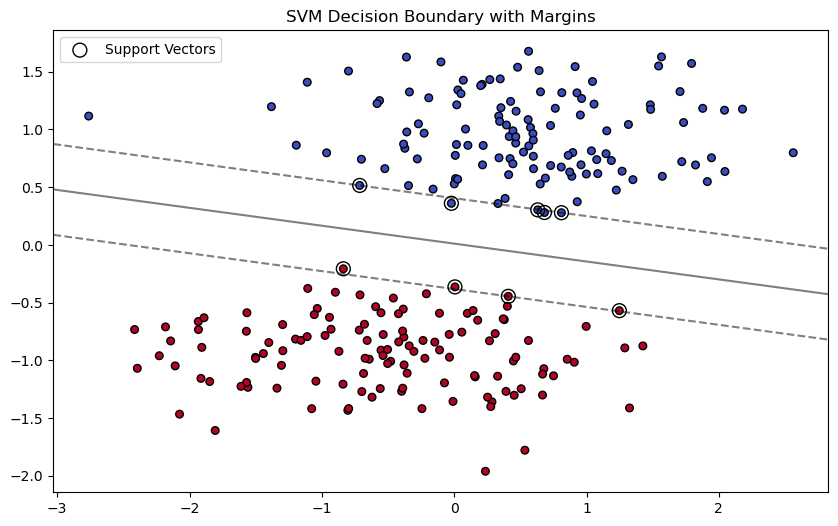

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import confusion_matrix, accuracy_score

# 1. THE DATA
# Synthetic Data: Two distinct groups of chips with some overlap
from sklearn.datasets import make_blobs
X, y = make_blobs(n_samples=300, centers=2, random_state=6, cluster_std=1.2)

# 2. THE SPLIT
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. SCALING (Critical for SVM!)
# SVM tries to maximize the physical distance (margin) between points.
# If one feature is 1000x larger than the other, the margin will be distorted.
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 4. TRAINING (The Separator)
# kernel='linear' draws a straight line.
# kernel='rbf' (Radial Basis Function) can draw curves around complex clusters.
svm_model = SVC(kernel='linear', C=1.0) 
svm_model.fit(X_train_scaled, y_train)

# 5. EVALUATION
predictions = svm_model.predict(X_test_scaled)
accuracy = accuracy_score(y_test, predictions)

print(f"Accuracy: {accuracy:.2%}")
print("Confusion Matrix:\n", confusion_matrix(y_test, predictions))

# 6. VISUALIZATION (Seeing the Margin)
# We plot the decision boundary and the "Support Vectors" (the points on the edge)
plt.figure(figsize=(10, 6))

# Plot the data points
plt.scatter(X_train_scaled[:, 0], X_train_scaled[:, 1], c=y_train, cmap='coolwarm', s=30, edgecolors='k')

# Plot the decision function
ax = plt.gca()
xlim = ax.get_xlim()
ylim = ax.get_ylim()

# Create grid to evaluate model
xx = np.linspace(xlim[0], xlim[1], 30)
yy = np.linspace(ylim[0], ylim[1], 30)
YY, XX = np.meshgrid(yy, xx)
xy = np.vstack([XX.ravel(), YY.ravel()]).T
Z = svm_model.decision_function(xy).reshape(XX.shape)

# Plot decision boundary and margins
ax.contour(XX, YY, Z, colors='k', levels=[-1, 0, 1], alpha=0.5,
           linestyles=['--', '-', '--'])

# Highlight Support Vectors (the points that define the boundary)
ax.scatter(svm_model.support_vectors_[:, 0], svm_model.support_vectors_[:, 1], s=100,
           linewidth=1, facecolors='none', edgecolors='k', label='Support Vectors')

plt.title('SVM Decision Boundary with Margins')
plt.legend()
plt.show()